<a href="https://colab.research.google.com/github/lokanathsql/lokanathsql-CMP7005_Programming_for_Data_Analysis/blob/main/CMP7005_PRAC1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMP7005 PRAC1

## IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Assessment_dataset/PRSA_Data_Dongsi_20130301-20170228.csv')

df.head()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')


Mounted at /content/drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## task 1: data handling

### load dataset

In [3]:
# Urban Stations

dongsi = pd.read_csv(
    '/content/drive/MyDrive/Assessment_dataset/PRSA_Data_Dongsi_20130301-20170228.csv'
)

guanyuan = pd.read_csv(
    '/content/drive/MyDrive/Assessment_dataset/PRSA_Data_Guanyuan_20130301-20170228.csv'
)

# Rural/Suburban Stations

huairou = pd.read_csv(
    '/content/drive/MyDrive/Assessment_dataset/PRSA_Data_Huairou_20130301-20170228.csv'
)

changping = pd.read_csv(
    '/content/drive/MyDrive/Assessment_dataset/PRSA_Data_Changping_20130301-20170228.csv'
)

#### ADD STATION COLUMN

In [4]:
dongsi['Station'] = 'Dongsi'
guanyuan['Station'] = 'Guanyuan'
huairou['Station'] = 'Huairou'
changping['Station'] = 'Changping'


### MERGE DATASETS

In [5]:
df = pd.concat(
    [dongsi, guanyuan, huairou, changping],
    ignore_index=True
)

#### BASIC DATA UNDERSTANDING

In [6]:
print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA TYPES")
print(df.dtypes)

print("\nDATASET INFORMATION")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nSTATISTICAL SUMMARY")
print(df.describe())



FIRST 5 ROWS
   No  year  month  day  hour  PM2.5  PM10  SO2   NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    9.0   9.0  3.0  17.0  300.0  89.0  -0.5   
1   2  2013      3    1     1    4.0   4.0  3.0  16.0  300.0  88.0  -0.7   
2   3  2013      3    1     2    7.0   7.0  NaN  17.0  300.0  60.0  -1.2   
3   4  2013      3    1     3    3.0   3.0  5.0  18.0    NaN   NaN  -1.4   
4   5  2013      3    1     4    3.0   3.0  7.0   NaN  200.0  84.0  -1.9   

     PRES  DEWP  RAIN   wd  WSPM station Station  
0  1024.5 -21.4   0.0  NNW   5.7  Dongsi  Dongsi  
1  1025.1 -22.1   0.0   NW   3.9  Dongsi  Dongsi  
2  1025.3 -24.6   0.0  NNW   5.3  Dongsi  Dongsi  
3  1026.2 -25.5   0.0    N   4.9  Dongsi  Dongsi  
4  1027.1 -24.5   0.0  NNW   3.2  Dongsi  Dongsi  

DATASET SHAPE
(140256, 19)

COLUMN NAMES
Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station',
       'Station'],
      dtyp

## TASK 2 — DATA PREPROCESSING

### HANDLE MISSING VALUES

In [7]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())


### HANDLE CATEGORICAL MISSING VALUES

In [8]:
df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

### REMOVE DUPLICATES

In [9]:
print("\nBEFORE REMOVING DUPLICATES")
print(df.shape)

df.drop_duplicates(inplace=True)

print("\nAFTER REMOVING DUPLICATES")
print(df.shape)


BEFORE REMOVING DUPLICATES
(140256, 19)

AFTER REMOVING DUPLICATES
(140256, 19)


### CREATE DATETIME COLUMN

In [10]:
df['datetime'] = pd.to_datetime(
    df[['year', 'month', 'day', 'hour']]
)


### FEATURE ENGINEERING

In [11]:
df['Month'] = df['datetime'].dt.month
df['Year'] = df['datetime'].dt.year
df['Day'] = df['datetime'].dt.day
df['Hour'] = df['datetime'].dt.hour


### AQI CATEGORY CREATION

In [12]:
def aqi_category(pm):

    if pm <= 50:
        return 'Good'

    elif pm <= 100:
        return 'Moderate'

    elif pm <= 150:
        return 'Unhealthy'

    else:
        return 'Hazardous'


df['AQI_Category'] = df['PM2.5'].apply(aqi_category)



### FINAL DATASET CHECK

In [13]:
print("\nFINAL DATASET")
print(df.head())


FINAL DATASET
   No  year  month  day  hour  PM2.5  PM10  SO2   NO2     CO  ...   wd  WSPM  \
0   1  2013      3    1     0    9.0   9.0  3.0  17.0  300.0  ...  NNW   5.7   
1   2  2013      3    1     1    4.0   4.0  3.0  16.0  300.0  ...   NW   3.9   
2   3  2013      3    1     2    7.0   7.0  7.0  17.0  300.0  ...  NNW   5.3   
3   4  2013      3    1     3    3.0   3.0  5.0  18.0  900.0  ...    N   4.9   
4   5  2013      3    1     4    3.0   3.0  7.0  39.0  200.0  ...  NNW   3.2   

   station  Station            datetime Month  Year Day Hour AQI_Category  
0   Dongsi   Dongsi 2013-03-01 00:00:00     3  2013   1    0         Good  
1   Dongsi   Dongsi 2013-03-01 01:00:00     3  2013   1    1         Good  
2   Dongsi   Dongsi 2013-03-01 02:00:00     3  2013   1    2         Good  
3   Dongsi   Dongsi 2013-03-01 03:00:00     3  2013   1    3         Good  
4   Dongsi   Dongsi 2013-03-01 04:00:00     3  2013   1    4         Good  

[5 rows x 25 columns]


### TASK 2 - EDA

### UNIVARIATE ANALYSIS

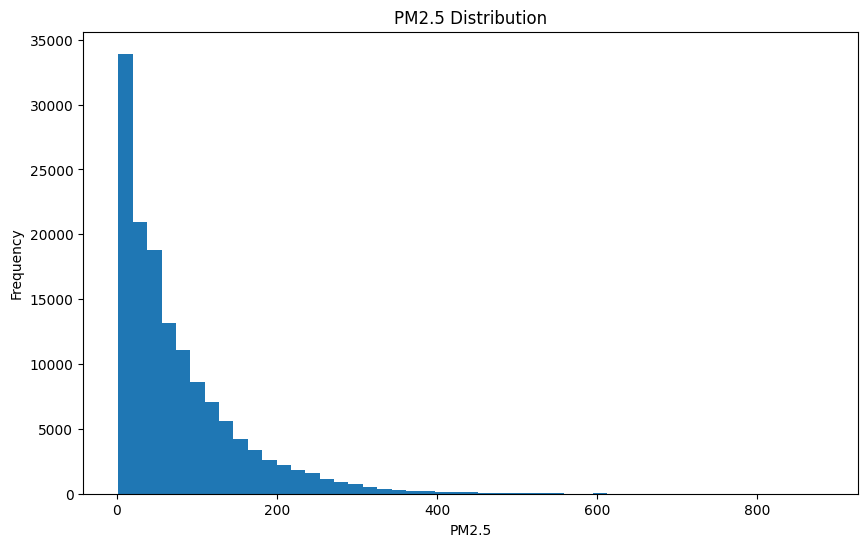

In [14]:
# PM2.5 DISTRIBUTION

plt.figure(figsize=(10, 6))

pm25_values = np.array(df['PM2.5'].dropna(), dtype=float)

plt.hist(
    pm25_values,
    bins=np.linspace(pm25_values.min(), pm25_values.max(), 50)
)

plt.title('PM2.5 Distribution')
plt.xlabel('PM2.5')
plt.ylabel('Frequency')

plt.show()


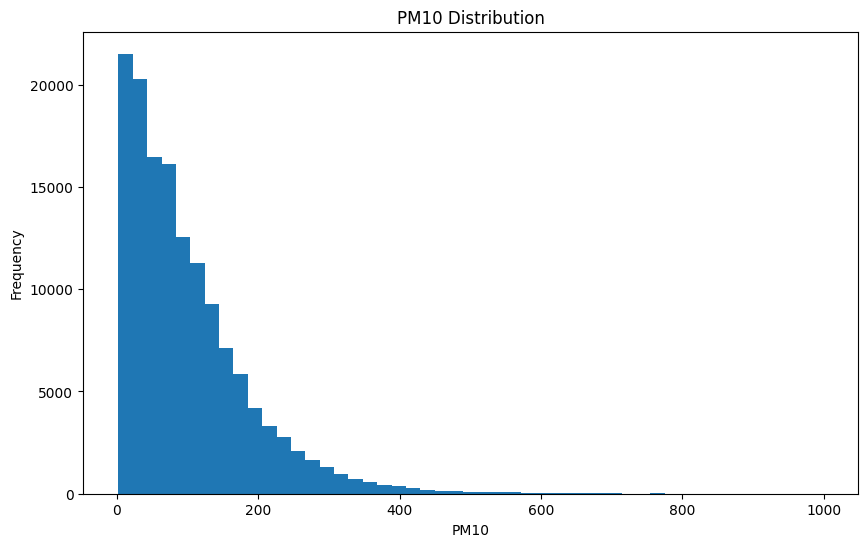

In [15]:
# PM10 DISTRIBUTION

plt.figure(figsize=(10, 6))

pm10_values = np.array(df['PM10'].dropna(), dtype=float)

plt.hist(
    pm10_values,
    bins=np.linspace(pm10_values.min(), pm10_values.max(), 50)
)

plt.title('PM10 Distribution')
plt.xlabel('PM10')
plt.ylabel('Frequency')

plt.show()


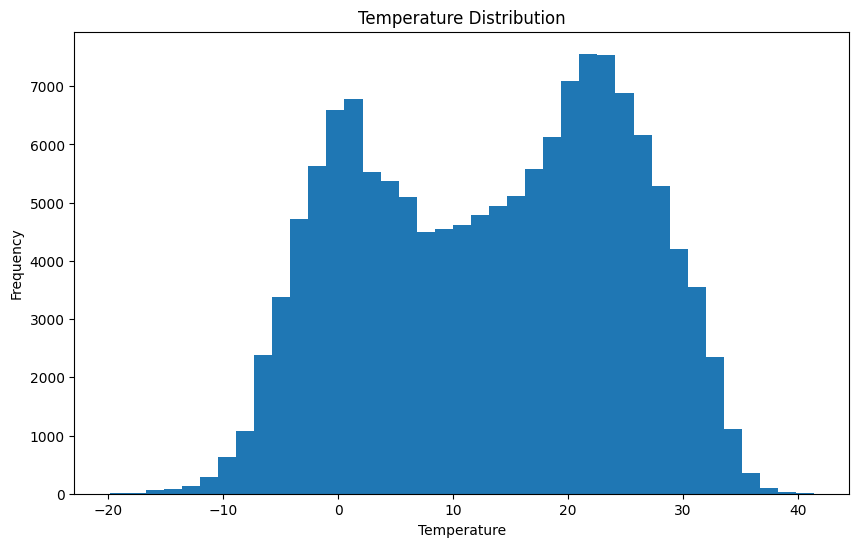

In [16]:
# TEMPERATURE DISTRIBUTION

plt.figure(figsize=(10, 6))

temp_values = np.array(df['TEMP'].dropna(), dtype=float)

plt.hist(
    temp_values,
    bins=np.linspace(temp_values.min(), temp_values.max(), 40)
)

plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')

plt.show()

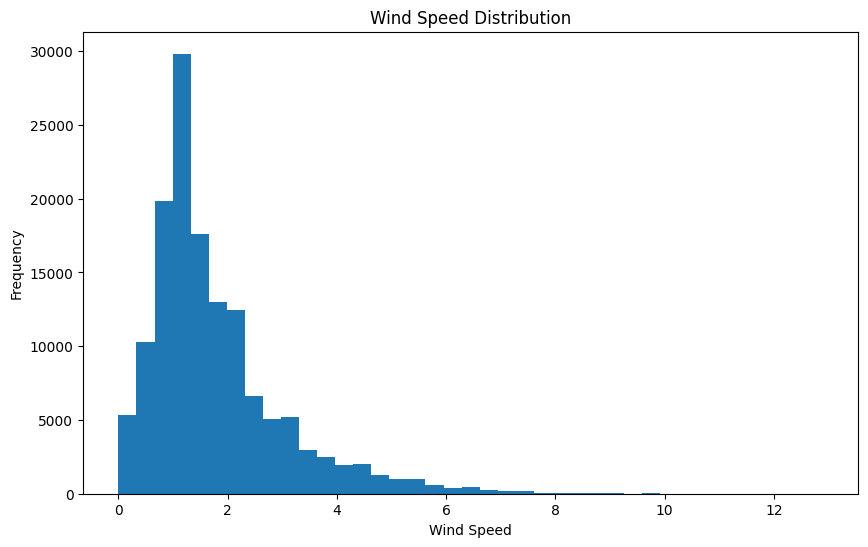

In [17]:
# WIND SPEED DISTRIBUTION

plt.figure(figsize=(10, 6))

wspm_values = np.array(df['WSPM'].dropna(), dtype=float)

plt.hist(
    wspm_values,
    bins=np.linspace(wspm_values.min(), wspm_values.max(), 40)
)

plt.title('Wind Speed Distribution')
plt.xlabel('Wind Speed')
plt.ylabel('Frequency')

plt.show()

### BIVARIATE ANALYSIS

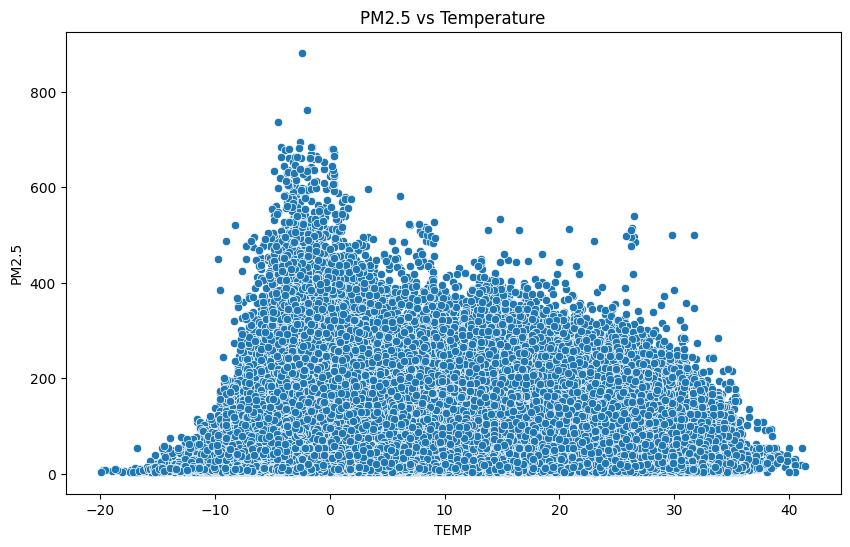

In [18]:
# PM2.5 VS TEMPERATURE

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='TEMP',
    y='PM2.5',
    data=df
)

plt.title('PM2.5 vs Temperature')

plt.show()


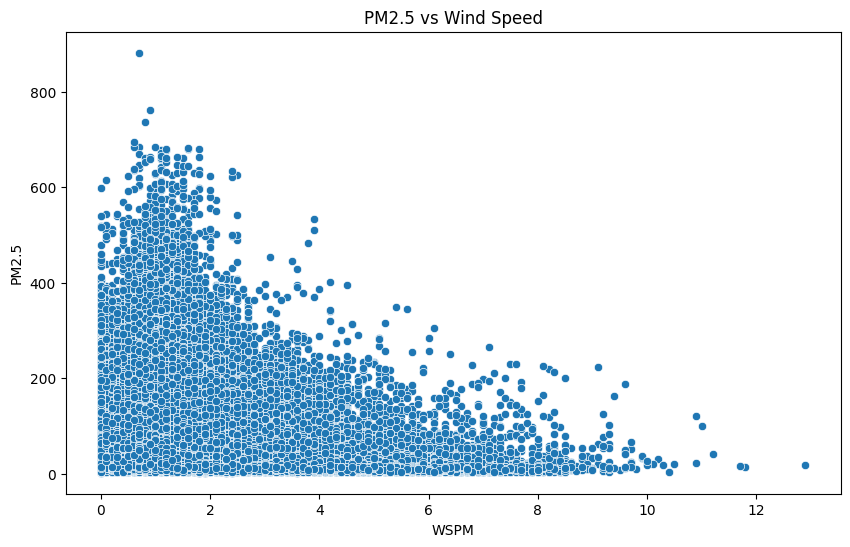

In [19]:
# PM2.5 VS WIND SPEED

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='WSPM',
    y='PM2.5',
    data=df
)

plt.title('PM2.5 vs Wind Speed')

plt.show()

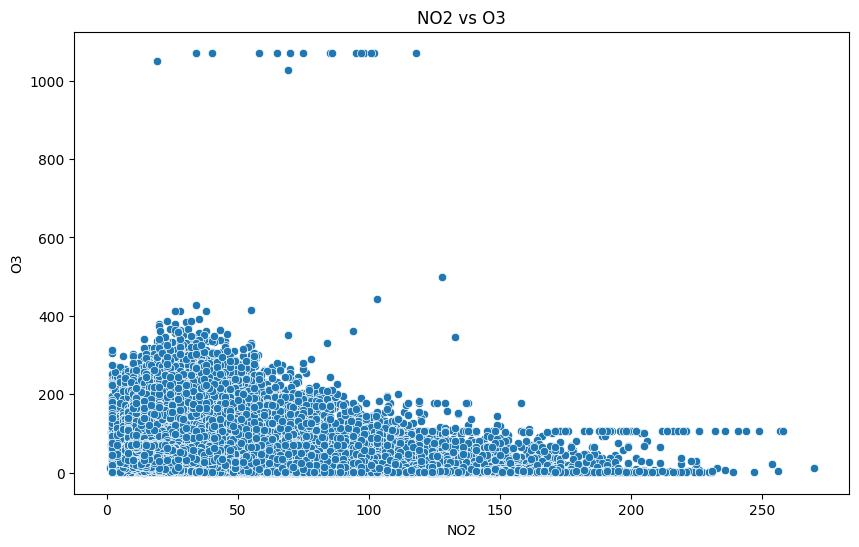

In [20]:
# NO2 VS O3

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='NO2',
    y='O3',
    data=df
)

plt.title('NO2 vs O3')

plt.show()

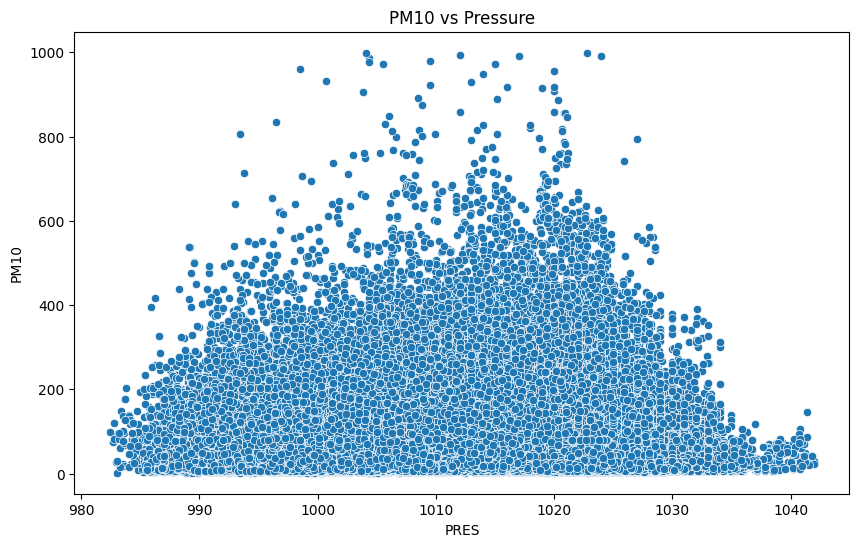

In [21]:
# PM10 VS PRESSURE

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='PRES',
    y='PM10',
    data=df
)

plt.title('PM10 vs Pressure')

plt.show()

### MULTIVARIATE ANALYSIS

In [22]:
correlation = df.corr(numeric_only=True)

print("\nCORRELATION MATRIX")
print(correlation)


CORRELATION MATRIX
             No          year         month           day          hour  \
No     1.000000  9.695331e-01  4.318051e-02  1.776442e-02  6.838683e-04   
year   0.969533  1.000000e+00 -2.020099e-01 -5.569082e-03 -2.915669e-15   
month  0.043181 -2.020099e-01  1.000000e+00  1.052232e-02 -8.872790e-17   
day    0.017764 -5.569082e-03  1.052232e-02  1.000000e+00  2.262076e-18   
hour   0.000684 -2.915669e-15 -8.872790e-17  2.262076e-18  1.000000e+00   
PM2.5 -0.026191 -2.716958e-02  5.430034e-03  2.383096e-03  1.798866e-02   
PM10  -0.032396 -2.503193e-02 -2.970140e-02  2.351349e-02  6.027564e-02   
SO2   -0.240504 -1.868231e-01 -2.015902e-01 -5.776202e-03  2.426072e-02   
NO2   -0.026555 -3.837002e-02  4.960480e-02  6.191913e-04  7.546248e-03   
CO     0.034648  2.450698e-02  3.912364e-02 -1.565641e-02 -1.819150e-02   
O3    -0.088892 -6.275807e-02 -9.903638e-02  1.908532e-03  2.716674e-01   
TEMP  -0.120878 -1.503932e-01  1.318360e-01  1.410631e-02  1.434795e-01   
PRES 

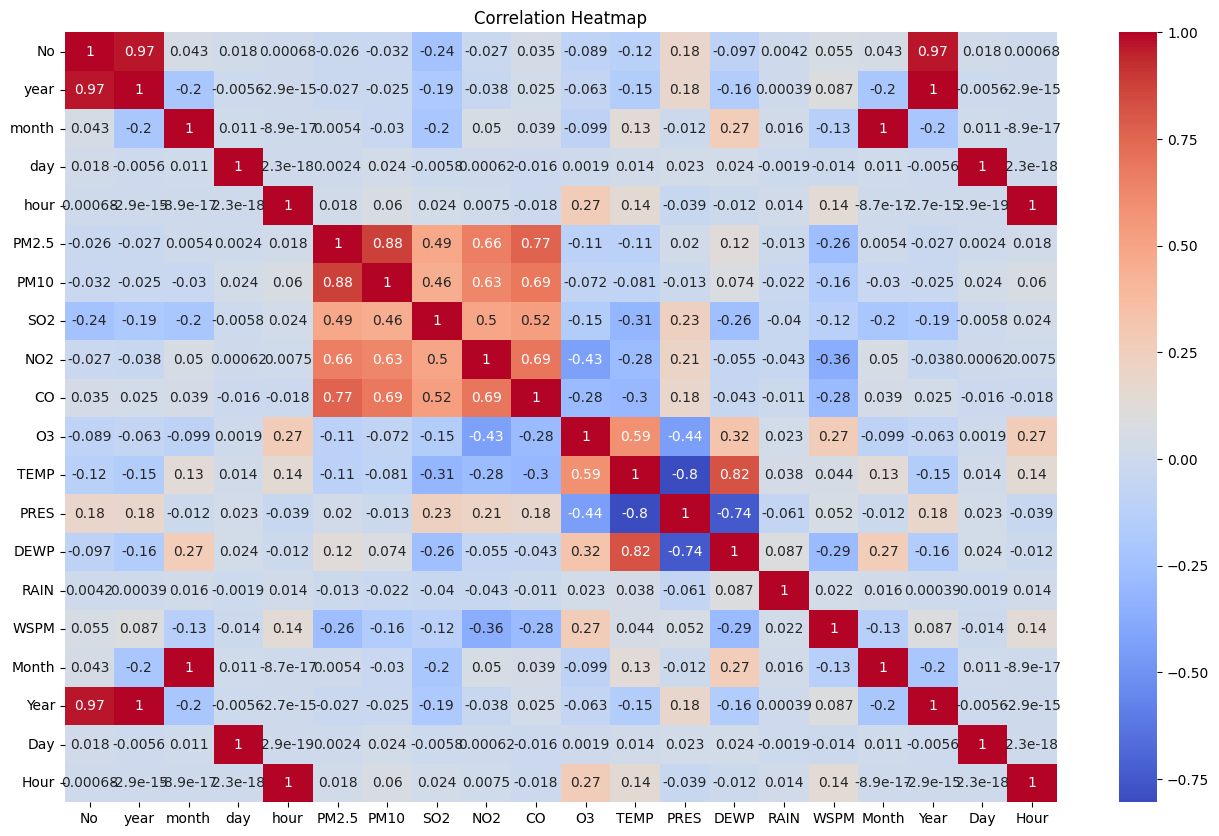

In [23]:
# HEATMAP
plt.figure(figsize=(16, 10))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### STATION COMPARISON ANALYSIS

In [24]:
station_pm25 = df.groupby('Station')['PM2.5'].mean()

print("\nAVERAGE PM2.5 BY STATION")
print(station_pm25)


AVERAGE PM2.5 BY STATION
Station
Changping    70.700211
Dongsi       85.484289
Guanyuan     82.407506
Huairou      69.174481
Name: PM2.5, dtype: float64


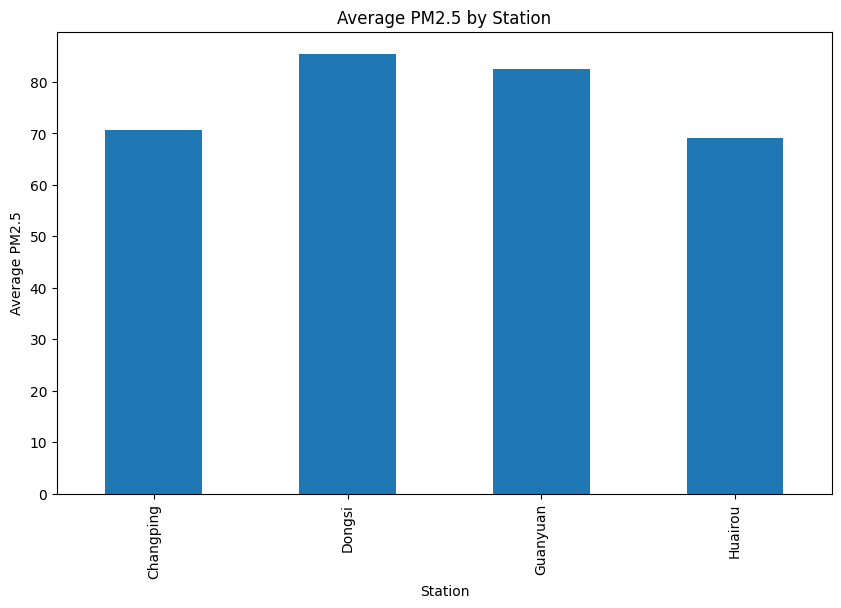

In [25]:
# BAR CHART

plt.figure(figsize=(10, 6))

station_pm25.plot(kind='bar')

plt.title('Average PM2.5 by Station')
plt.xlabel('Station')
plt.ylabel('Average PM2.5')

plt.show()


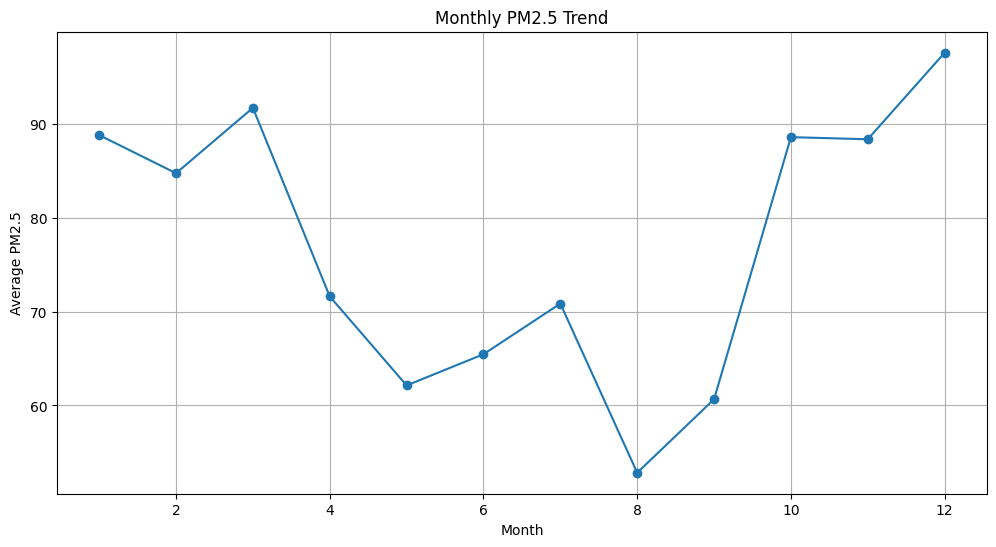

In [26]:
# TIME SERIES ANALYSIS

monthly_pm25 = df.groupby('Month')['PM2.5'].mean()

plt.figure(figsize=(12, 6))

monthly_pm25.plot(marker='o')

plt.title('Monthly PM2.5 Trend')
plt.xlabel('Month')
plt.ylabel('Average PM2.5')

plt.grid(True)

plt.show()


## TASK 3 - MACHINE LEARNING MODEL

### FEATURE SELECTION

In [27]:

X = df[
    [
        'TEMP',
        'PRES',
        'DEWP',
        'RAIN',
        'WSPM'
    ]
]

y = df['PM2.5']


### TRAIN TEST SPLIT

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### FEATURE SCALING

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### LINEAR REGRESSION

In [30]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("\nLINEAR REGRESSION RESULTS")

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score:",
      r2_score(y_test, lr_pred))


LINEAR REGRESSION RESULTS
MAE: 51.242779495749346
RMSE: 70.7769543266369
R2 Score: 0.1560475800915181


### DECISION TREE REGRESSOR

In [31]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)

print("\nDECISION TREE RESULTS")

print("MAE:",
      mean_absolute_error(y_test, dt_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, dt_pred)))

print("R2 Score:",
      r2_score(y_test, dt_pred))


DECISION TREE RESULTS
MAE: 47.57006444553283
RMSE: 78.04789051069348
R2 Score: -0.02625801339793643


### RANDOM FOREST REGRESSOR

In [32]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

print("\nRANDOM FOREST RESULTS")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:",
      r2_score(y_test, rf_pred))


RANDOM FOREST RESULTS
MAE: 38.25861441681469
RMSE: 57.187803975215324
R2 Score: 0.4490133679205419


### MODEL COMPARISON TABLE

In [33]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],

    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

print("\nMODEL COMPARISON")
print(results)


MODEL COMPARISON
               Model        MAE       RMSE  R2 Score
0  Linear Regression  51.242779  70.776954  0.156048
1      Decision Tree  47.570064  78.047891 -0.026258
2      Random Forest  38.258614  57.187804  0.449013


### BEST MODEL

In [34]:
best_model = rf_model

print("\nBEST MODEL SELECTED")
print("Random Forest Regressor")


BEST MODEL SELECTED
Random Forest Regressor


In [35]:
# FEATURE IMPORTANCE
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf_model.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFEATURE IMPORTANCE")
print(importance)



FEATURE IMPORTANCE
  Feature  Importance
0    TEMP    0.302086
2    DEWP    0.297839
1    PRES    0.238164
4    WSPM    0.145257
3    RAIN    0.016654


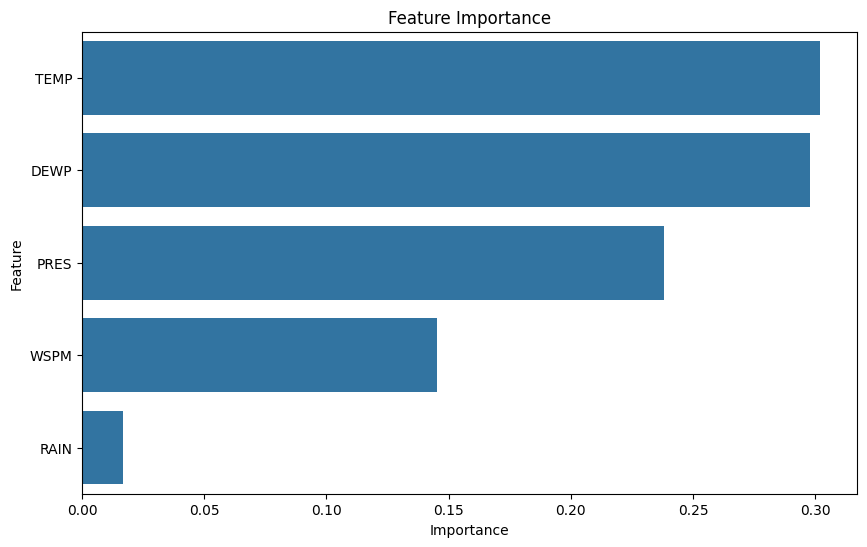

In [36]:
# FEATURE IMPORTANCE GRAPH

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()


# SAVE BEST MODEL FOR FLASK FRONTEND

In [37]:
import joblib

# SAVE RANDOM FOREST MODEL

joblib.dump(
    rf_model,
    'best_model.pkl'
)

# SAVE SCALER

joblib.dump(
    scaler,
    'scaler.pkl'
)

print("Best model saved successfully")
print("Scaler saved successfully")

Best model saved successfully
Scaler saved successfully
